# Sanskrit Epic Research Suite
### Unified Analysis: Mahabharata & Ramayana

This notebook provides a comprehensive data-driven insight into both major epics. By leveraging computational linguistics and structural analysis, we explore the scale, metrical regularity, and distinguishing markers of the Sanskrit epic world.

In [11]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.epic_utils import (
    configure_sanskrit_plots, 
    load_epic_dataset, 
    calculate_distinction_scores,
    count_syllables,
    calculate_shannon_entropy
)

plt.style.use('ggplot')
configure_sanskrit_plots()
sns.set_theme(style="whitegrid")

Devanagari font loaded: Noto Sans Devanagari


## 1. Unified Data Ingestion
Loading the complete Mahabharata and Ramayana datasets for comparative analysis.

In [12]:
print("Loading Mahabharata (MBH)...")
df_mbh = load_epic_dataset('../data/raw/mahabharata/')
parva_map = {1:"Adi", 2:"Sabha", 3:"Vana", 4:"Virata", 5:"Udyoga", 6:"Bhishma", 7:"Drona", 8:"Karna", 9:"Shalya", 10:"Sauptika", 11:"Stri", 12:"Shanti", 13:"Anushasana", 14:"Ashvamedhika", 15:"Ashramavasika", 16:"Mausala", 17:"Mahaprasthanika", 18:"Svargarohana"}
df_mbh['book_name'] = df_mbh['book'].map(parva_map)

print("Loading Ramayana (RAM)...")
df_ram = load_epic_dataset('../data/raw/ramayana/')
kanda_map = {1:"Bala", 2:"Ayodhya", 3:"Aranya", 4:"Kishkindha", 5:"Sundara", 6:"Yuddha", 7:"Uttara"}
df_ram['book_name'] = df_ram['book'].map(kanda_map)

print(f"Loaded {len(df_mbh)} lines from MBH and {len(df_ram)} lines from RAM.")

Loading Mahabharata (MBH)...
Loading Ramayana (RAM)...
Loaded 158502 lines from MBH and 38043 lines from RAM.


## 2. Structural Scale Comparison
Visualizing the scale of the 18 Parvas of the Mahabharata versus the 7 Kandas of the Ramayana.

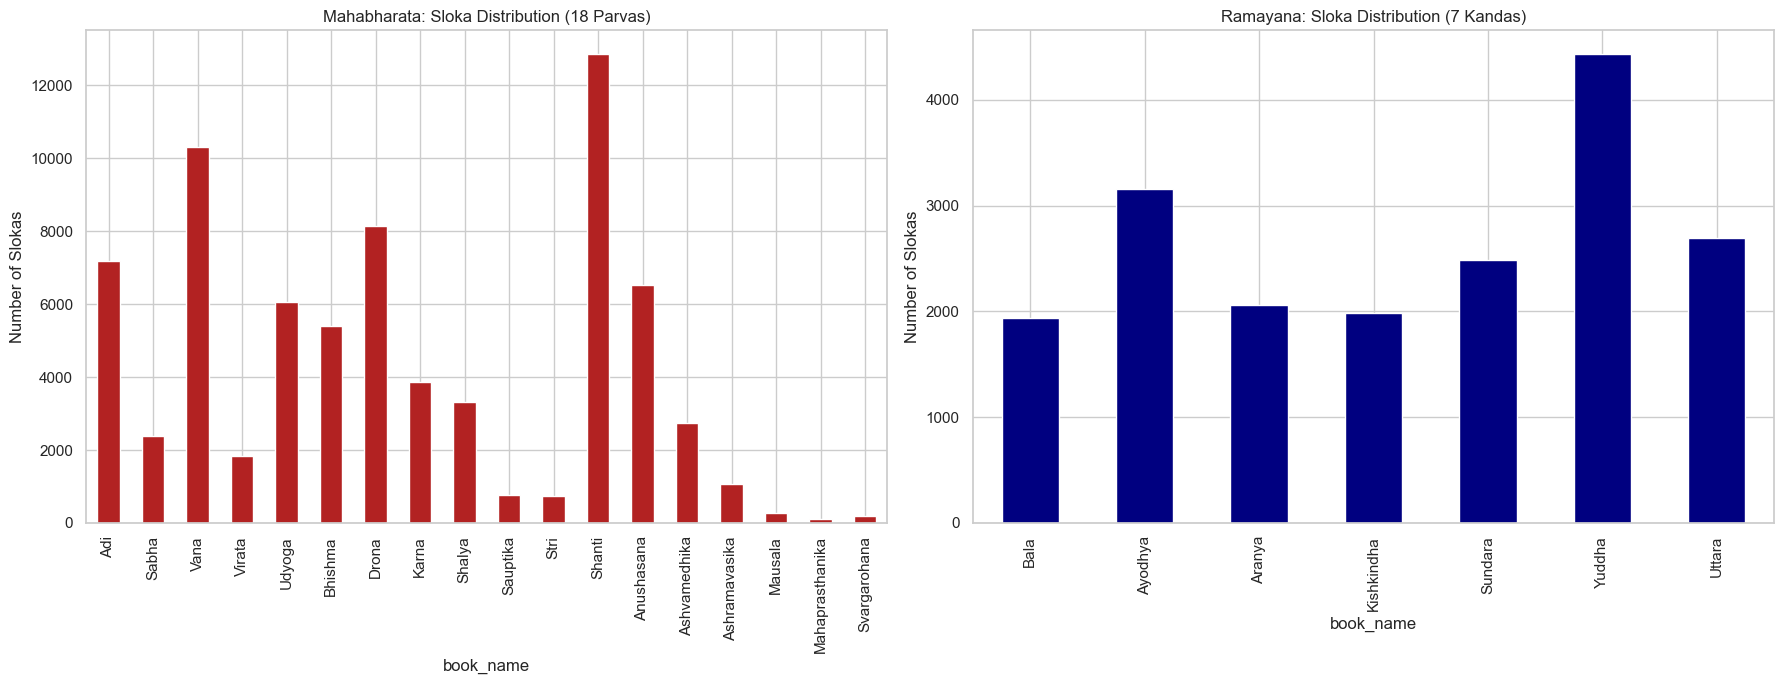

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

struct_mbh = df_mbh.groupby('book_name')['sloka_id'].nunique().reindex(parva_map.values())
struct_mbh.plot(kind='bar', color='firebrick', ax=ax[0])
ax[0].set_title("Mahabharata: Sloka Distribution (18 Parvas)")
ax[0].set_ylabel("Number of Slokas")

struct_ram = df_ram.groupby('book_name')['sloka_id'].nunique().reindex(kanda_map.values())
struct_ram.plot(kind='bar', color='navy', ax=ax[1])
ax[1].set_title("Ramayana: Sloka Distribution (7 Kandas)")
ax[1].set_ylabel("Number of Slokas")

plt.tight_layout()
plt.show()

## 3. Linguistic Distinction Scores
Identifying unique markers for each epic. We calculate which words are common in one epic but significantly rarer in the other.

In [14]:
def get_word_freq(df):
    text = " ".join(df['clean_text'].dropna())
    words = text.split()
    return Counter(words)

freq_mbh = get_word_freq(df_mbh)
freq_ram = get_word_freq(df_ram)

print("Top Distinguishing Terms for Mahabharata (MBH vs RAM):")
scores_mbh = calculate_distinction_scores(freq_mbh, freq_ram)
for i, (word, score) in enumerate(list(scores_mbh.items())[:15]):
    print(f"{i+1}. {word} (Score: {score:.2f})")

print("\nTop Distinguishing Terms for Ramayana (RAM vs MBH):")
scores_ram = calculate_distinction_scores(freq_ram, freq_mbh)
for i, (word, score) in enumerate(list(scores_ram.items())[:15]):
    print(f"{i+1}. {word} (Score: {score:.2f})")

Top Distinguishing Terms for Mahabharata (MBH vs RAM):
1. न (Score: 1.12)
2. च (Score: 1.10)
3. स (Score: 0.91)
4. उवाच (Score: 0.79)
5. ते (Score: 0.65)
6. तु (Score: 0.57)
7. हि (Score: 0.55)
8. मे (Score: 0.43)
9. तथा (Score: 0.39)
10. वै (Score: 0.38)
11. ततः (Score: 0.37)
12. यथा (Score: 0.34)
13. तं (Score: 0.34)
14. ततो (Score: 0.32)
15. वा (Score: 0.31)

Top Distinguishing Terms for Ramayana (RAM vs MBH):
1. स (Score: 1.10)
2. च (Score: 0.91)
3. न (Score: 0.89)
4. तु (Score: 0.82)
5. ते (Score: 0.61)
6. हि (Score: 0.58)
7. मे (Score: 0.44)
8. तं (Score: 0.41)
9. ततः (Score: 0.37)
10. तस्य (Score: 0.35)
11. दृष्ट्वा (Score: 0.33)
12. श्रुत्वा (Score: 0.33)
13. वा (Score: 0.32)
14. यथा (Score: 0.31)
15. मम (Score: 0.31)


## 4. Advanced Linguistic Metrics
Deep-diving into the metrical adherence and information density of the epics.

### 4.1 Metrical Regularity (Syllable Count Distribution)
Analyzing how strictly each epic follows the 8-syllable (Anushtubh) pada structure.

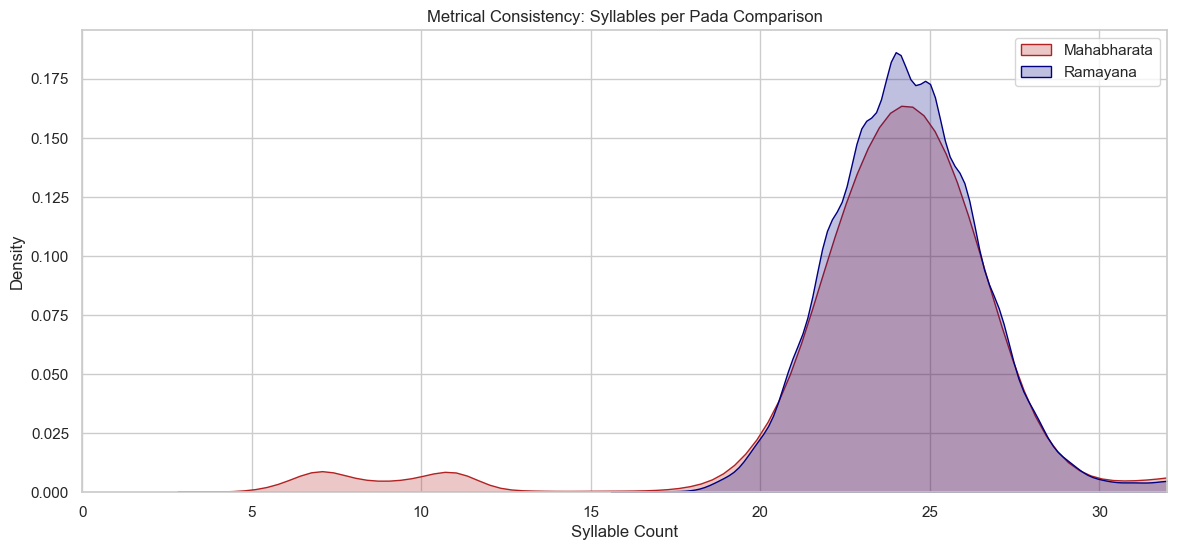

In [15]:
# Sample 10,000 lines for metrical analysis
sample_mbh = df_mbh['clean_text'].sample(10000).apply(count_syllables)
sample_ram = df_ram['clean_text'].sample(10000).apply(count_syllables)

plt.figure(figsize=(14, 6))
sns.kdeplot(sample_mbh, fill=True, label="Mahabharata", color="firebrick")
sns.kdeplot(sample_ram, fill=True, label="Ramayana", color="navy")
plt.title("Metrical Consistency: Syllables per Pada Comparison")
plt.xlabel("Syllable Count")
plt.ylabel("Density")
plt.xlim(0, 32) # Visual focus on Anushtubh/Trishtubh range
plt.legend()
plt.show()

### 4.2 Lexical Diversity & Vocabulary Richness
Comparing the unique word counts and the Type-Token Ratio (TTR).

In [16]:
def calculate_lexical_stats(freq_counter):
    total_words = sum(freq_counter.values())
    unique_words = len(freq_counter)
    ttr = unique_words / total_words if total_words > 0 else 0
    # Percentage of Hapax Legomena (words appearing once)
    hapax_count = sum(1 for word in freq_counter if freq_counter[word] == 1)
    hapax_pct = (hapax_count / unique_words) * 100 if unique_words > 0 else 0
    return total_words, unique_words, ttr, hapax_pct

mbh_stats = calculate_lexical_stats(freq_mbh)
ram_stats = calculate_lexical_stats(freq_ram)

stats_summary = pd.DataFrame({
    "Metric": ["Total Words", "Unique Tokens", "Type-Token Ratio (TTR)", "Hapax Legomena %"],
    "Mahabharata": [mbh_stats[0], mbh_stats[1], f"{mbh_stats[2]:.4f}", f"{mbh_stats[3]:.1f}%"],
    "Ramayana": [ram_stats[0], ram_stats[1], f"{ram_stats[2]:.4f}", f"{ram_stats[3]:.1f}%"]
})
display(stats_summary)

,Metric,Mahabharata,Ramayana
0,Total Words,701329,170452
1,Unique Tokens,222086,67653
2,Type-Token Ratio (TTR),0.3167,0.3969
3,Hapax Legomena %,77.9%,78.7%


### 4.3 Book-wise Semantic Entropy (Information Density)
Mapping the 'surprise' or linguistic complexity for each Parva/Kanda.

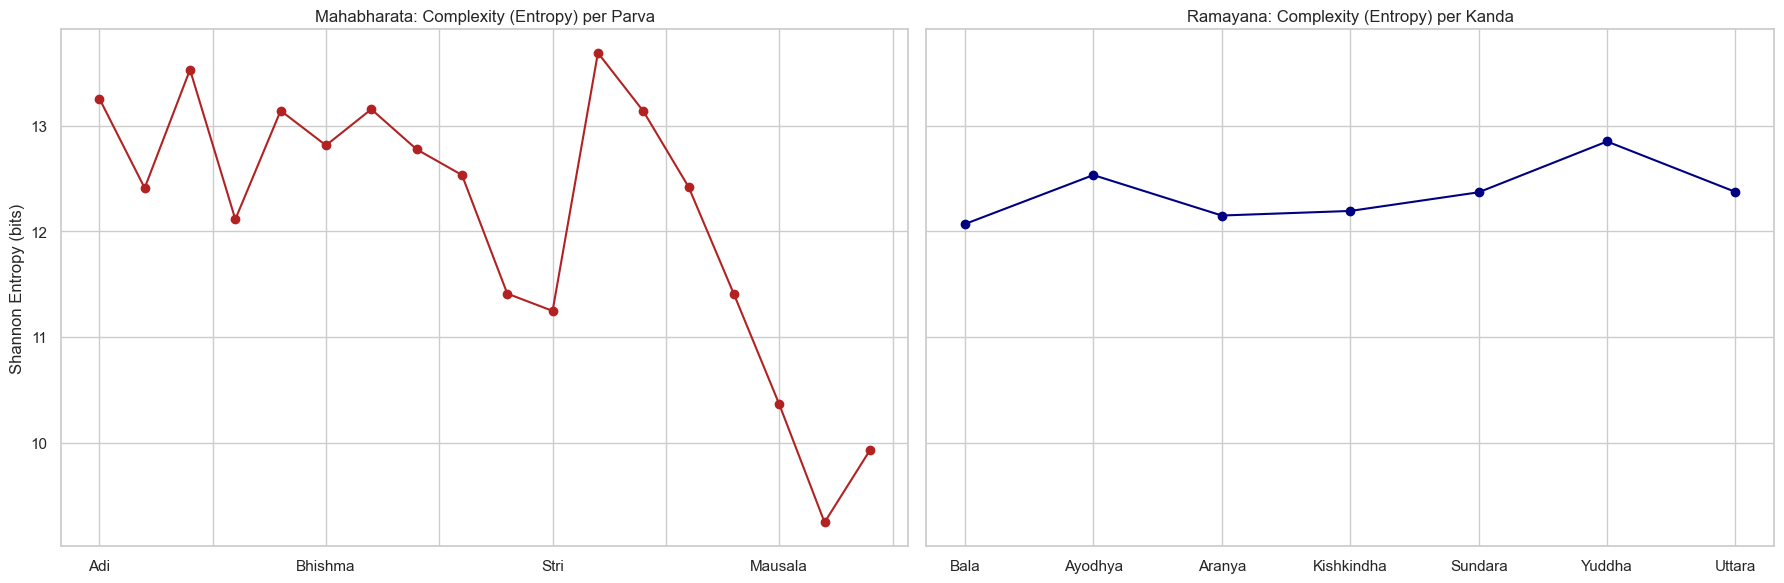

In [17]:
def get_book_entropy(df):
    book_entropies = {}
    for book_name, group in df.groupby('book_name'):
        tokens = " ".join(group['clean_text'].dropna()).split()
        entropy = calculate_shannon_entropy(tokens)
        book_entropies[book_name] = entropy
    return book_entropies

entropy_mbh = get_book_entropy(df_mbh)
entropy_ram = get_book_entropy(df_ram)

fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

pd.Series(entropy_mbh).reindex(parva_map.values()).plot(kind='line', marker='o', color='firebrick', ax=ax[0])
ax[0].set_title("Mahabharata: Complexity (Entropy) per Parva")
ax[0].set_ylabel("Shannon Entropy (bits)")

pd.Series(entropy_ram).reindex(kanda_map.values()).plot(kind='line', marker='o', color='navy', ax=ax[1])
ax[1].set_title("Ramayana: Complexity (Entropy) per Kanda")

plt.tight_layout()
plt.show()